# Análisis Exploratorio de Datos: Titanic

En esta actividad usaremos la base de datos de pasajeros del Titanic para practicar **análisis exploratorio de datos (EDA)**.

El objetivo no es hacer la mayor cantidad posible de gráficos, sino aprender a **usar los datos para responder preguntas**.

## Pregunta de investigación

> **¿Qué características de los pasajeros estaban asociadas con la supervivencia en el Titanic?**


## Librerías de visualización
### Matplotlib

Matplotlib tiene dos métodos para crear una figura, uno directo y otro enfocado a objetos. 
Algunos links de interés:

- Argumentos que reciben matplotlib: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
- Más opciones de gráficos en https://matplotlib.org/2.0.2/gallery.html
- Para una lista de colores disponibles en Matplotlib, https://matplotlib.org/stable/gallery/color/named_colors.html
- Explicación de plt y ax https://towardsdatascience.com/what-are-the-plt-and-ax-in-matplotlib-exactly-d2cf4bf164a9


### Seaborn
Proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos. A diferencia de Matplotlib, ésta no viene por defecto en Pandas. 
Galería de gráficos: https://seaborn.pydata.org/examples/index.html

Otro link útil para visualizaciones en Python: https://python-graph-gallery.com/


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("white")


## Carga de los datos

Cada fila de la base de datos corresponde a **un pasajero**.

Las principales características disponibles son:

- `Survived`: supervivencia, 0 = no, 1 = sí
- `Pclass`: clase del pasajero, 1 = primera, 2 = segunda, 3 = tercera
- `Sex`: sexo
- `Age`: edad
- `SibSp`: número de hermanos/as o cónyuges a bordo
- `Parch`: número de padres o hijos a bordo
- `Ticket`: identificador del pasaje
- `Fare`: tarifa pagada
- `Cabin`: cabina
- `Embarked`: puerto de embarque, C = Cherbourg, Q = Queenstown, S = Southampton


In [2]:
titanic = pd.read_csv("titanic_semana_02.csv")
titanic.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### **cuáles variables son numéricas y cuáles son categóricas?**



# Parte 1: Comprender la muestra

## ¿Quiénes eran los pasajeros del Titanic?

Antes de estudiar la supervivencia, necesitamos comprender a quiénes representan los datos.

Preguntas iniciales:

- ¿Cuántos pasajeros hay?
- ¿Qué características contiene la base de datos?
- ¿Cómo se distribuyen por sexo y clase?
- ¿Qué edades aparecen?
- ¿Cuánto pagaron por sus pasajes?
- ¿Viajaban solos o acompañados?
- ¿Desde qué puerto embarcaron?

Revise la estructura general de la tabla: dimensión, columnas, estadística básica, etc.

### Ejemplo de gráfico: pasajeros por sexo

Para una característica categórica podemos comenzar contando cuántos pasajeros pertenecen a cada grupo.


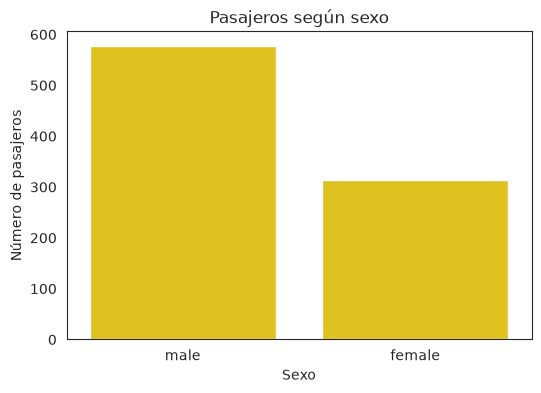

In [3]:
plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Sex", color="gold")

plt.xlabel("Sexo")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según sexo")

plt.show()


### Ahora usted

**1. Grafique la cantidad de pasajeros según `Pclass`.**

- Qué clase contiene más pasajeros?
La clase 3
- La muestra está balanceada entre las tres clases?
No, hay claramente más personas en la clase 3. En las clases 1 y 2 hay una cantidad similar de personas entre sí


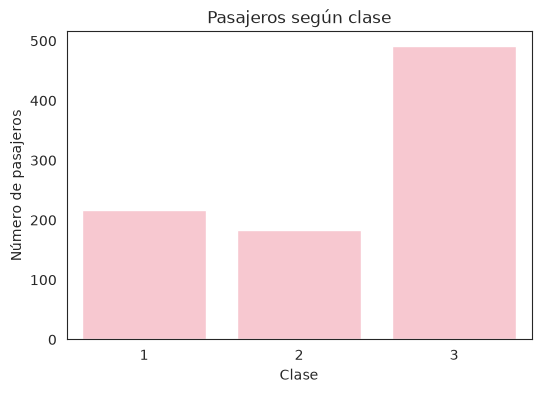

In [4]:
plt.figure(figsize=(6,4))

sns.countplot(data=titanic,x="Pclass", color="pink")

plt.xlabel("Clase")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según clase")

plt.show()


**2. Explore la distribución de `Age` con un histograma.**

Pruebe, por ejemplo, con 15, 30 y 50 bins.

- ¿Qué edades son más frecuentes?
Entre edades de 20 a 30 años
- ¿La distribución parece simétrica?
No parece simétrica, hay una tendencia a las edades mencionadas anteriormente, y la curva no decae de la misma forma para edades pequeñas y altas
- ¿El número de bins cambia su interpretación?
Absolutamente, al utilizar 15 bins podríamos decir que la mayoría tiene edades cercanas a 30, pero al utilizar 50 bins observamos que hay una mayor frecuencia en edades cercanas a 20. 

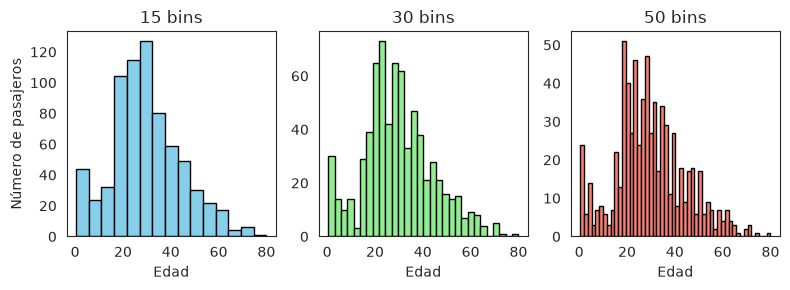

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(8, 3))

axes[0].hist(titanic["Age"].dropna(), bins=15, color="skyblue", edgecolor="black")
axes[0].set_title("15 bins")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Número de pasajeros")

axes[1].hist(titanic["Age"].dropna(), bins=30, color="lightgreen", edgecolor="black")
axes[1].set_title("30 bins")
axes[1].set_xlabel("Edad")

axes[2].hist(titanic["Age"].dropna(), bins=50, color="salmon", edgecolor="black")
axes[2].set_title("50 bins")
axes[2].set_xlabel("Edad")

plt.tight_layout()
plt.show()


**3. Explore la distribución de `Fare`.**

Puede usar un histograma o un boxplot.

- ¿La distribución es simétrica? Para nada, se nota una gran tendencia a haber pagado poco por su ticket y pocas personas que pagaron bastante
- ¿Existen tarifas muy superiores al resto? Existe una tarifa de 500 bastante superior al resto, esta se escapa de los valores usuales encontrados
- ¿Qué podría significar esto? Que existen outliers dentro de la muestra


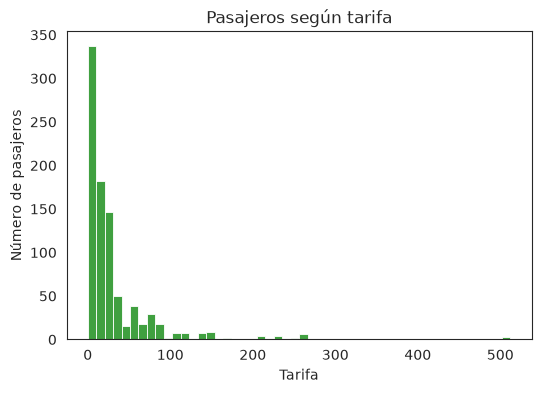

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(data=titanic, x="Fare",bins=50, color="green")
plt.xlabel("Tarifa")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según tarifa")
plt.show()

# Parte 2: Calidad de los datos

## ¿Qué información falta y por qué podría importar?

Antes de interpretar cualquier patrón debemos revisar la calidad de los datos.

Nos interesa detectar:

- valores faltantes
- características con mucha información incompleta
- valores extremos o sospechosos
- decisiones de limpieza que puedan cambiar nuestras conclusiones


In [7]:
datos_faltantes = titanic.isnull().sum()
datos_faltantes


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Ejemplo de gráfico: valores faltantes

Podemos visualizar cuántos datos faltan en cada característica.


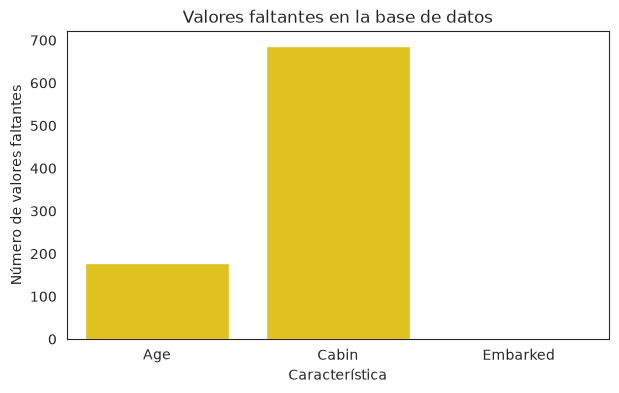

In [8]:
faltantes = datos_faltantes[datos_faltantes > 0]

plt.figure(figsize=(7,4))

sns.barplot(x=faltantes.index, y=faltantes.values, color='gold')

plt.xlabel("Característica")
plt.ylabel("Número de valores faltantes")
plt.title("Valores faltantes en la base de datos")

plt.show()


### Ahora usted

Observe especialmente `Age`, `Cabin` y `Embarked`.

**1. Compare la media y la mediana de `Age`.**

- Son similares? Si, son valores bastante cercanos.
- Es la media una buena representación de una edad típica? Yo diría que si, para efectos prácticos son casi el mismo valor.


In [9]:
titanic["Age"].mean()
titanic["Age"].median()
print("Promedio:",round(titanic["Age"].mean(),2), "Mediana:", titanic["Age"].median())


Promedio: 29.7 Mediana: 28.0


**2. La edad tiene datos faltantes.**

- Le parece razonable reemplazar todas las edades faltantes por la media? Si, ya que es representativo de la muestra.
- Qué problema podría producir esa decisión en la distribución de edades? Encontraríamos una distribución con aun mayor tendencia a edades de 30 años.
- Qué otra estrategia consideraría? Podría rellenarse con valores aleatorios de edades que ya se han registrado. 


**3. `Cabin` tiene una gran cantidad de valores faltantes.**

- Intentaría rellenarlos? No intentaría rellenarla, ya que en su mayoría no se conoce el valor, y por ende los valores que si tenemos pueden no necesariamente ser representativos de la muestra. Además al ser el número de identificación de cabina, es probablemente un valor individual y no necesariamente que se repita.
- Eliminaría la característica? Si, ya que al no tener suficiente información no es un criterio representativo de toda la muestra.
- Podría el hecho de conocer o no la cabina contener información por sí mismo? Podría ser, quizás nos serviría para conocer en que lugar del barco estaba la persona cuando este se hundió, pero tampoco es necesariamente cierto.

No hay una única respuesta correcta: justifique su decisión.


In [10]:
titanic["Cabin"]

0       NaN
1       C85
2       NaN
3      C123
4       NaN
       ... 
886     NaN
887     B42
888     NaN
889    C148
890     NaN
Name: Cabin, Length: 891, dtype: str

**4. `Embarked` tiene pocos datos faltantes.**

- Qué estrategia simple usaría en este caso? Haría un recuento de las proporciones de cada opción y rellenaría las faltantes en base a ese recuento.
- Por qué el tratamiento puede ser distinto al de `Cabin`? Porque son muy pocas las personas que no tienen esta información, por lo que tenemos aproximadamente una tendencia que puede ser representativa de los datos.


In [11]:
titanic["Embarked"]

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: str

# Parte 3: Explorar relaciones entre características

## ¿Cómo se relacionan las características de los pasajeros?

Después de estudiar las características individualmente, podemos comenzar a buscar estructura en los datos.

Preguntas posibles:

- La tarifa pagada está relacionada con la clase?
- Las edades son similares en todas las clases?
- Quiénes viajaban acompañados?
- Hay características que contienen información parcialmente similar?



### Ejemplo de gráfico: tarifa según clase

Un boxplot permite comparar la distribución de una característica numérica entre distintos grupos.


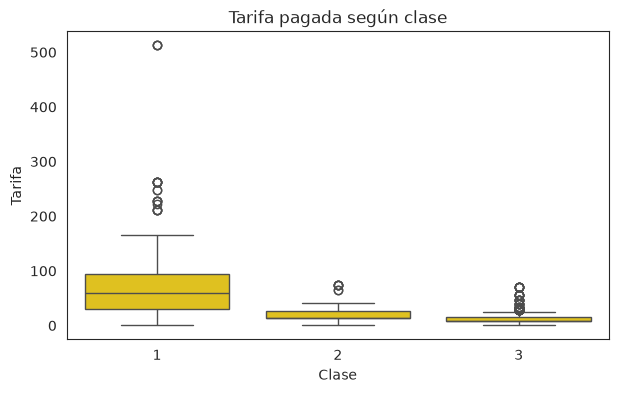

In [12]:
plt.figure(figsize=(7,4))

sns.boxplot(data=titanic, x="Pclass", y="Fare", color='gold')

plt.xlabel("Clase")
plt.ylabel("Tarifa")
plt.title("Tarifa pagada según clase")

plt.show()


### Preguntas

- La tarifa parece estar relacionada con la clase? Si, aquellos que son de clase 1 tienden a pagar más que los de clase 3
- Hay dispersión dentro de cada clase? Hay bastante dispersión específifcamente en la clase 1
- Existen valores extremos? Si, la tarifa de 500 para clase 1
- Diría que `Fare` y `Pclass` contienen exactamente la misma información? No, ya que no hay una relación directa entre estas variables. 


### Ahora usted

**1. Compare la distribución de edad entre las tres clases.**

Use un gráfico que permita comparar las distribuciones.

- Los pasajeros tienen edades similares en todas las clases? Por lo general si, pero de todas formas hay tendencias distintas para cada clase.
- Qué diferencias observa? En la clase 1 la mediana de edad es cercana a 40, mientras que para la clase 3 la mediana es cercana a 25, es decir para clase 1 encontramos personas de mayor edad que en las otras clases.


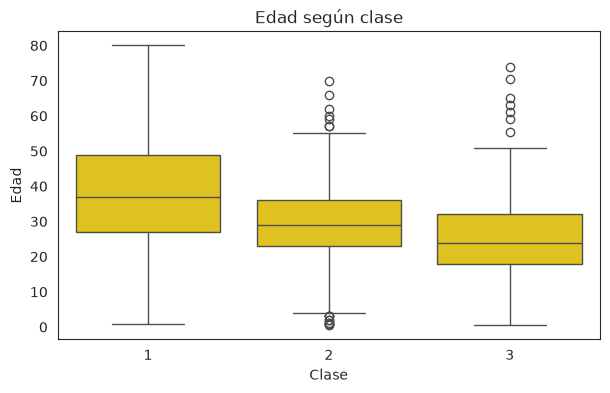

In [13]:
plt.figure(figsize=(7,4))

sns.boxplot(data=titanic, x="Pclass", y="Age", color='gold')

plt.xlabel("Clase")
plt.ylabel("Edad")
plt.title("Edad según clase")

plt.show()



**2. Las características `SibSp` y `Parch` contienen información sobre familiares a bordo.**

Construya una nueva característica llamada `Familia`, que represente el número total de personas del grupo familiar incluyendo al propio pasajero:

\[
Familia = SibSp + Parch + 1
\]


In [14]:
# Complete el código

titanic["Familia"] = titanic["SibSp"]+titanic["Parch"]+1
titanic["Familia"]


0      2
1      2
2      1
3      2
4      1
      ..
886    1
887    1
888    4
889    1
890    1
Name: Familia, Length: 891, dtype: int64

**3. Explore la nueva característica `Familia`.**

- La mayoría de los pasajeros viajaba sola o acompañada? La gran mayoría viajaban solos
- Hay grupos familiares muy grandes? Si, pero son muy pocos alrededor de 10 personas
- Cambiaría su interpretación si solo mirara `SibSp` o `Parch` por separado? La interpretación sería similar, ya que la tendencia para cada variable por separado es similar


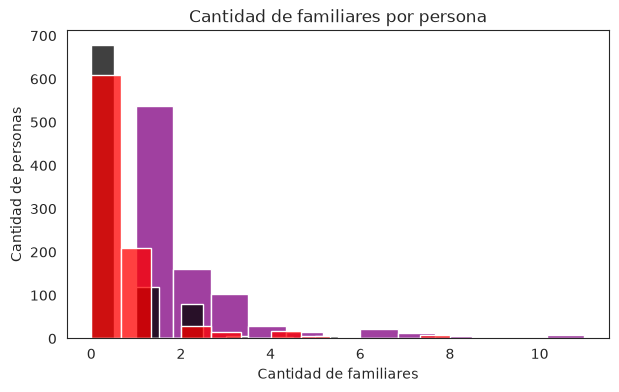

In [15]:
plt.figure(figsize=(7,4))

sns.histplot(data=titanic, x="Familia",bins=12, color="purple")

sns.histplot(data=titanic, x="Parch",bins=12, color="k")
sns.histplot(data=titanic, x="SibSp",bins=12, color="red")

plt.xlabel("Cantidad de familiares")
plt.ylabel("Cantidad de personas")
plt.title("Cantidad de familiares por persona")

plt.show()



# Parte 4: Investigar la supervivencia

## ¿Qué características estaban asociadas con la supervivencia?

Ahora incorporaremos `Survived`, la variable que queremos comprender.

Investigaremos si la supervivencia está asociada con características como:

- sexo
- clase
- edad
- tamaño del grupo familiar


### Ejemplo de gráfico: supervivencia según sexo

Como `Survived` toma valores 0 y 1, su promedio dentro de un grupo corresponde a la **fracción de pasajeros que sobrevivió**.

`seaborn.barplot` calcula por defecto la media de la variable del eje vertical.


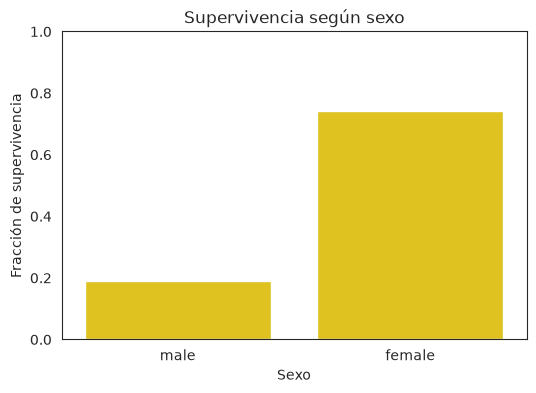

In [16]:
plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Sex", y="Survived", errorbar=None, color='gold')

plt.xlabel("Sexo")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según sexo")
plt.ylim(0,1)

plt.show()


### Preguntas

- La fracción de supervivencia es similar para hombres y mujeres? Claramente hay más mujeres que hombres que sobrevivieron
- Podemos concluir a partir de este gráfico por qué existe la diferencia? No podemos saberlo


### Ahora usted

**1. Explore la supervivencia según `Pclass`.**

- Hay diferencias entre las tres clases? Si, hay una clara diferencia en la supervivencia de cada clase
- Existe una tendencia? si, las personas de clase 3 son las que menos sobrevivieron, mientras que las personas de clase 1 sobrevivieron más.


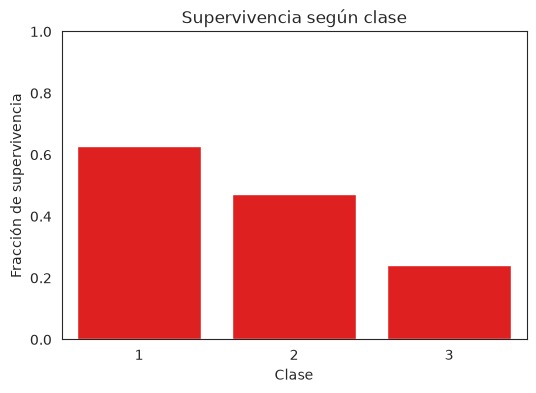

In [17]:
plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Pclass", y="Survived", errorbar=None, color='red')

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase")
plt.ylim(0,1)

plt.show()

**2. Explore la supervivencia según edad.**

Puede comparar las distribuciones de edad de quienes sobrevivieron y quienes no sobrevivieron.

- La edad parece estar asociada con supervivencia? Si esta asociada, personas de mayor edad pareciera que sobreviven menos que las de menor edad.
- Hay algún grupo de edad que llame particularmente su atención? el rango entre 0 y 10 años, este tiene una fracción de supervivencia mucho mayor que el resto.


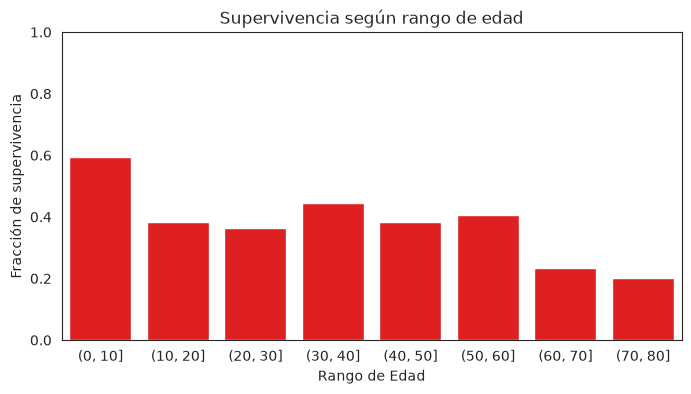

In [18]:
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
titanic['Age_Bins'] = pd.cut(titanic['Age'], bins=bins)

plt.figure(figsize=(8, 4))

sns.barplot(data=titanic, x="Age_Bins", y="Survived", errorbar=None, color='red')

plt.xlabel("Rango de Edad")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según rango de edad")
plt.ylim(0, 1)
plt.show()


**3. Explore la supervivencia según `Familia`.**

- Viajar solo parece favorable o desfavorable? Yo diría que ninguna de las 2, ya que no es una gran fracción ni una baja fracción de supervivencia. 
- La relación parece simple? No, a medida que aumenta la cantidad de familiares pareciera ser incrementa la fracción de supervivientes. Pero luego esta disminuye drásticamente, y luego vuelve a aumentar.
- Qué ocurre con los grupos familiares grandes? Pareciera que tienen una fracción de supervivencia similar a las personas que van solas.


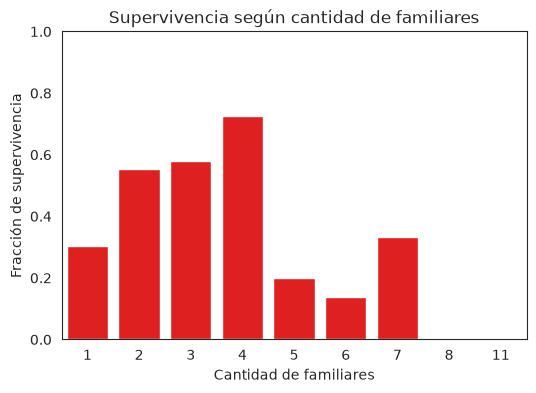

In [20]:
plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Familia", y="Survived", errorbar=None, color='red')

plt.xlabel("Cantidad de familiares")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según cantidad de familiares")
plt.ylim(0,1)

plt.show()

# Parte 5: Agregar contexto

## ¿Cambia una relación cuando consideramos otra característica?

Una relación global puede esconder comportamientos diferentes dentro de la muestra.

Ya estudiamos por separado:

- `Pclass` y supervivencia
- `Sex` y supervivencia

Ahora podemos preguntar:
 **¿La relación entre clase y supervivencia es igual para hombres y mujeres?**

Esta es una forma sencilla de análisis multivariado: consideramos varias características al mismo tiempo.


### Ejemplo de gráfico: clase, sexo y supervivencia


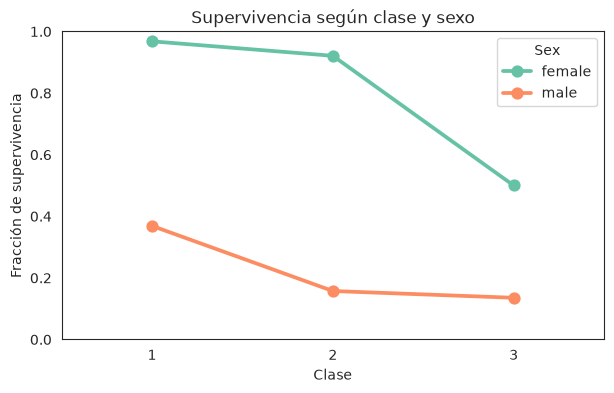

In [21]:
plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",
              hue="Sex",
              palette="Set2",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y sexo")
plt.ylim(0,1)

plt.show()


### Preguntas sobre el ejemplo

- La relación entre clase y supervivencia es igual para hombres y mujeres? La relación es similar, pero para hombres hay una fracción mucho menor de supervivencia en todas las clases.
- Qué información se perdía cuando mirábamos solamente `Pclass`? La cantidades de hombres y mujeres sobrevivientes en cada clase. 
- Qué información se perdía cuando mirábamos solamente `Sex`? Las clases correspondientes de los sobrevivientes. 
- Hay algún grupo particularmente favorecido o desfavorecido? Si, la fracción de sobrevivencia en mujeres de clase 1 es casi del 100%, totalmente favorecidas. Por otra parte, los hombres de clase 3 se ven totalmente desfavorecidos con una fracción de sobrevivencia muy baja.



### Ahora usted

**1. Cree una característica `Persona` con tres categorías:**

- `mujer`
- `hombre`
- `niño/a`

Considere como niño/a a un pasajero menor de 16 años.


In [54]:
# Complete el código
niño = titanic["Age"]<16
mujer = (titanic["Age"]>= 16) & (titanic["Sex"] == "female")
hombre = (titanic["Age"]>= 16) & (titanic["Sex"] == "male")

titanic.loc[niño, "Persona"] = "niño/a"
titanic.loc[mujer, "Persona"] = "mujer"
titanic.loc[hombre, "Persona"] = "hombre"

# Revise el resultado
titanic["Persona"].value_counts()


Persona
hombre    413
mujer     218
niño/a     83
Name: count, dtype: int64

**2. Explore la supervivencia según `Persona` y `Pclass`.**

- Los niños presentan el mismo patrón que los adultos? No, para la clase 2 la fracción de supervivencia es mayor en niños
- La clase sigue siendo importante dentro de cada grupo? Si, permite distinguir diferencias en cada tipo de persona
- Qué combinación de características parece asociarse con la mayor supervivencia? Niños de clase 2


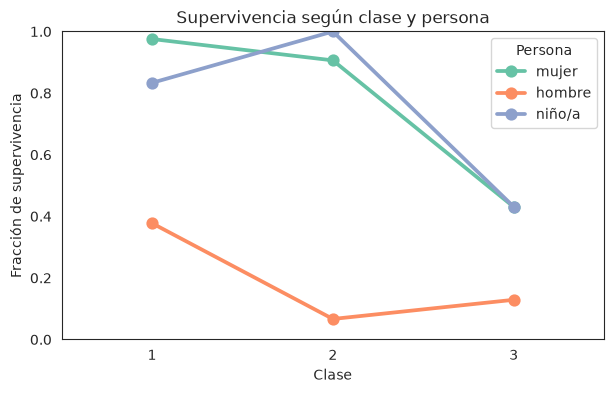

In [78]:
plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",
              hue="Persona",
              palette="Set2",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y persona")
plt.ylim(0,1)

plt.show()

**3. Elija una relación adicional para explorar incorporando una tercera característica.**

Algunas ideas:

- edad + sexo + supervivencia;
- tamaño de familia + clase + supervivencia;
- puerto de embarque + clase + supervivencia.

No necesita crear una figura complicada. El objetivo es responder una pregunta concreta.

**Escriba primero la pregunta que quiere investigar y luego construya el gráfico.**


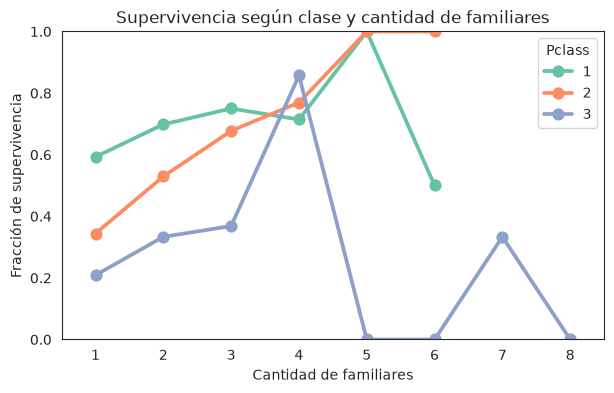

In [68]:
# Pregunta: ¿La tasa de supervivencia se relaciona a familias más numerosas?
#¿Y como se relaciona la clase con la cantidad de familiares? 

# Código:
plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Familia",
              y="Survived",
              hue="Pclass",
              palette="Set2",
              errorbar=None)

plt.xlabel("Cantidad de familiares")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y cantidad de familiares")
plt.ylim(0,1)

plt.show()


EXTRA

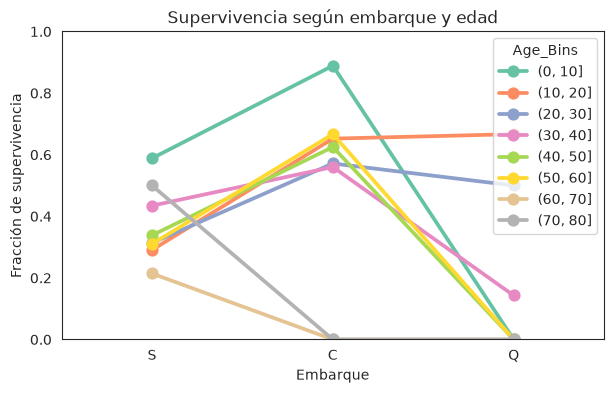

In [86]:
plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Embarked",
              y="Survived",
              hue="Age_Bins",
              palette="Set2",
              errorbar=None)

plt.xlabel("Embarque")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según embarque y edad")
plt.ylim(0,1)

plt.show()

# Parte 6: Conclusión

## ¿Qué podemos concluir?

El EDA no termina cuando encontramos diferencias entre grupos.

Queremos distinguir entre:

### Observación
Algo que vemos directamente en los datos.

### Interpretación
Cómo describimos ese patrón.

### Hipótesis
Una explicación posible que debería ser evaluada con más información.

Por ejemplo:

> **Observación:** las mujeres presentan una mayor fracción de supervivencia que los hombres.

- **Podemos concluir, solo a partir de esta base de datos, que durante la evacuación se dio prioridad a mujeres y niños?** No necesariamente.
- **Qué información adicional necesitaríamos para evaluar esa hipótesis?** Necesitariamos saber las instrucciones reales que se dieron en el momento.
- **Qué otras explicaciones podrían producir el mismo patrón de supervivencia?** Que las mujeres y niños sepan mantener la calma y acatar ordenes, mientras que los hombres podrían desesperarse.

## Síntesis del análisis

Revise todas las figuras construidas y responda:

### 1. Quiénes eran los pasajeros del Titanic? 
Eran en su mayoría hombres que viajaban solos, edad cercana a los 20 o 30 años, eran de tercera clase, y pagaron poco por su ticket.

Describa brevemente la muestra considerando, al menos:

- sexo
- clase
- edad
- tamaño de familia.


### 2. Qué características estaban asociadas con la supervivencia?
 En su mayoría eran niños/as o mujeres que viajaban en familia de clase 1. 

Considere:

- sexo
- clase
- edad
- viajar solo o acompañado.



### 3. Qué relaciones cambiaron al considerar varias características al mismo tiempo? 
Que las familias numerosas (mayor a 5 integrantes) sobrevivieron más en familias de clase 2, y en familias de clase 1 o 3 hay menor sobrevivencia. 

Use como ejemplo al menos uno de los análisis multivariados realizados.


### 4. Encontró características que contienen información relacionada? 
Si, se relacionan bastantes las características de Tarifa y Clase; para clase 1 las tarifas pagadas son mayores. 

Explique al menos un caso.


### 5. Qué resultado le pareció más inesperado? 
Que hubiera mayor cantidad de sobrevivientes niños de clase 2 por sobre niños de clase 1 o 3. O en el gráfico de familiares también se ve esta tendencia de mayor sobrevivientes en clase 2. Una posible explicación sería que las personas de clase 1 fueron las primeras en ser salvadas y por ende las que más tiempo estuvieron en un bote en el mar con mucho frío, pudiendo morir congelados y dejando una fracción de supervivencia baja. 

Proponga una posible explicación, dejando claro qué parte corresponde a una observación y qué parte corresponde a una hipótesis.


# Conclusión final

## ¿Cuál es el perfil del pasajero típico que sobrevivió?

A partir de **sus propios resultados**, escriba una conclusión breve que caracterice al pasajero con mayor probabilidad de haber sobrevivido en esta muestra.

Considere, cuando corresponda:

- sexo
- edad
- clase
- tamaño del grupo familiar
- otras características que hayan resultado relevantes

Su respuesta debe estar respaldada por las figuras que construyó.


### Escriba aquí su conclusión

**El pasajero típico que sobrevivió...**

*(Complete con un párrafo breve basado en su análisis.)*


En base al análisis de los gráficos realizados, podríamos caracterizar al pasajero típico que sobrevivió como un niño o niña (no hay diferencia) menor a 16 años, de clase 2, con una familia numerosa (entre 6 a 7 integrantes), y lugar de embarque C (este indicó una mayor cantidad de supervivencia en niños).